# Credit Scoring con Bondora P2P

**Autor:** Marcelo Tolentino Vega  
**Objetivo:** Construir un modelo de credit scoring sobre el dataset público de Bondora que supere al rating interno publicado por la plataforma.

**Resultado:** XGBoost obtiene AUC = 0.7593 vs rating de Bondora = 0.6731 sobre 25,942 préstamos de validación. Mejora de +8.6 puntos AUC y +49.8% en coeficiente de Gini.

---

## Pipeline del proyecto

1. Carga y exploración del dataset
2. Definición del target (`bad_loan`)
3. Detección de data leakage
4. Preparación de datos
5. Modelo baseline: Logistic Regression
6. Modelo principal: XGBoost
7. Comparación contra Bondora
8. Generación de score crediticio
9. Exportación de resultados

## 1. Carga y exploración inicial

Conectamos Google Drive y cargamos el dataset público de Bondora (737,889 préstamos, 31 columnas).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
pd.set_option('display.max_columns', 100)
sns.set_style('whitegrid')

# Cargamos el dataset (ahora desde Excel)
df = pd.read_excel('/content/drive/MyDrive/Codigos/loan_dataset_investor.xlsx')
# Primera mirada
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 737,889
Columnas: 31


,loan_id,country,loan_issued_at,early_repaid_at,is_early_repaid_within_14_days,issued_amount,loan_status,loan_last_recorded_action_date_local,initial_interest_rate,nr_of_payments,principal_balance,principal_debt,principal_paid_total,interest_paid_total,extra_interest_paid_total,late_fee_paid_total,maintenance_fee_paid_total,is_default,next_payment_nr,next_payment_date_local,debt_occured_date_local,days_past_due_principal,months_in_default,months_on_book,loan_status_risk,repaid_amount_total,initial_loan_duration,combined_income,has_default_within_12_months,projected_npv_return,customer_risk_rating
0,0B3B642A-F923-49AD-84ED-B2A700BF1D0A,Finland,2025-03-21 11:45:56.040,2025-04-04 10:50:01.137,1.0,310.0,Repaid,2025-04-04,0.1780,1,0.00,0.0,310.00,1.99,0.00,0.0,0.00,0.0,0.0,NaT,NaT,NaN,NaN,0.0,Cancelled,311.99,12,2068.68,0.0,0.018929,F
1,4FD1927C-0E7F-4BF1-AED0-B268011E3E85,Finland,2025-01-17 17:27:25.447,NaT,NaN,414.0,Active,NaT,0.1780,120,301.49,0.0,112.51,70.83,0.00,0.0,3.27,0.0,11.0,2026-05-08,NaT,NaN,NaN,15.0,Active,186.61,18,1469.50,0.0,0.124216,B
2,7362E260-54DC-4798-8848-B18C00A59FCB,Finland,2024-06-11 10:04:52.427,2025-01-02 12:07:32.807,0.0,518.0,Repaid,2025-01-02,0.1877,8,0.00,0.0,518.00,51.60,0.00,0.0,0.00,0.0,0.0,NaT,NaT,NaN,NaN,6.0,Paid Up,569.60,60,4513.20,0.0,0.119993,B
3,8C7E5FB6-A673-4148-BCCF-B27500B0368E,Finland,2025-01-30 10:52:12.657,NaT,NaN,3731.0,Active,NaT,0.1780,75,3305.87,0.0,425.13,724.93,0.00,0.0,22.63,0.0,14.0,2026-05-04,NaT,NaN,NaN,15.0,Active,1172.69,60,1301.00,0.0,0.101424,C
4,BE865034-6041-4855-AB42-B196014FA0E8,Netherlands,2024-06-21 20:48:23.787,NaT,NaN,3432.0,Active,NaT,0.1056,38,2371.82,0.0,1060.18,549.66,0.29,0.0,60.65,0.0,1.0,2026-05-01,NaT,NaN,NaN,22.0,Active,1670.78,60,5194.70,0.0,0.109355,A


In [ ]:
# Tipos de datos y nulos por columna
df.info()
# Estadísticas descriptivas de las variables numéricas
df.describe()
# ¿Qué porcentaje de la cartera está en default?
print("Distribución de is_default:")
print(df['is_default'].value_counts(normalize=True) * 100)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737889 entries, 0 to 737888
Data columns (total 31 columns):
 #   Column                                Non-Null Count   Dtype         
---  ------                                --------------   -----         
 0   loan_id                               737889 non-null  object        
 1   country                               737889 non-null  object        
 2   loan_issued_at                        737889 non-null  datetime64[ns]
 3   early_repaid_at                       212484 non-null  datetime64[ns]
 4   is_early_repaid_within_14_days        212484 non-null  float64       
 5   issued_amount                         737889 non-null  float64       
 6   loan_status                           737889 non-null  object        
 7   loan_last_recorded_action_date_local  337604 non-null  datetime64[ns]
 8   initial_interest_rate                 737889 non-null  float64       
 9   nr_of_payments                        737889 non-null  int6

## 2. Definición correcta del target

La variable `is_default` del dataset captura default temporal, no outcome final. Construimos un target `bad_loan` agrupando préstamos defaulteados y castigados (Written Off), y filtramos a préstamos maduros únicamente para evitar sesgo por datos censurados.

Resultado: **404,028 préstamos maduros**, con bad rate real del **44.4%**.

In [ ]:
# ¿Qué valores únicos hay en loan_status?
print("loan_status (valores únicos):")
print(df['loan_status'].value_counts())
print()
print("loan_status_risk (valores únicos):")
print(df['loan_status_risk'].value_counts())

loan_status (valores únicos):
loan_status
Repaid                 333352
Active                 301158
Defaulted               99127
Returned                 4240
InPostFundingReview        12
Name: count, dtype: int64

loan_status_risk (valores únicos):
loan_status_risk
Active         301541
Paid Up        224749
Defaulted      100572
Written Off     78707
Cancelled       32317
Name: count, dtype: int64


In [ ]:
# Tabla cruzada: ¿qué loan_status se marcan como is_default?
print("Tabla cruzada loan_status vs is_default:")
print(pd.crosstab(df['loan_status'], df['is_default'], margins=True))
print()
print("Tabla cruzada loan_status_risk vs is_default:")
print(pd.crosstab(df['loan_status_risk'], df['is_default'], margins=True))


Tabla cruzada loan_status vs is_default:
is_default      0.0     1.0     All
loan_status                        
Active       301158       0  301158
Defaulted         0   99127   99127
Repaid       328177    1714  329891
All          629335  100841  730176

Tabla cruzada loan_status_risk vs is_default:
is_default           0.0     1.0     All
loan_status_risk                        
Active            301541       0  301541
Cancelled          26216       0   26216
Defaulted              0  100572  100572
Paid Up           223139       0  223139
Written Off        78438     269   78707
All               629334  100841  730175


In [ ]:
# 1) Filtramos solo préstamos "maduros" (outcome final conocido)
prestamos_maduros = ['Defaulted', 'Written Off', 'Paid Up']
df_modelo = df[df['loan_status_risk'].isin(prestamos_maduros)].copy()

# 2) Definimos nuestro target real: bad_loan = 1 si terminó mal, 0 si terminó bien
df_modelo['bad_loan'] = df_modelo['loan_status_risk'].isin(['Defaulted', 'Written Off']).astype(int)

# 3) Verificamos cuántos préstamos quedan y la nueva tasa de "malos"
print(f"Préstamos maduros: {len(df_modelo):,}")
print(f"Excluidos (Active + Cancelled + nulos): {len(df) - len(df_modelo):,}")
print()
print("Distribución del nuevo target (bad_loan):")
print(df_modelo['bad_loan'].value_counts())
print()
print(f"Tasa de malos (bad rate): {df_modelo['bad_loan'].mean()*100:.2f}%")

Préstamos maduros: 404,028
Excluidos (Active + Cancelled + nulos): 333,861

Distribución del nuevo target (bad_loan):
bad_loan
0    224749
1    179279
Name: count, dtype: int64

Tasa de malos (bad rate): 44.37%


## 3. Análisis exploratorio (EDA)

Analizamos el bad rate por país (Estonia, Finland, Spain, etc.), por rating de Bondora (AA hasta G), y la evolución temporal por año de desembolso.

In [ ]:
# Bad rate por país
print("=" * 50)
print("BAD RATE POR PAÍS")
print("=" * 50)
bad_pais = df_modelo.groupby('country').agg(
    n_prestamos=('bad_loan', 'count'),
    bad_rate=('bad_loan', 'mean')
).sort_values('n_prestamos', ascending=False)
bad_pais['bad_rate'] = (bad_pais['bad_rate'] * 100).round(2)
print(bad_pais)

print()

# Bad rate por rating de Bondora (nuestro futuro "rival" a vencer)
print("=" * 50)
print("BAD RATE POR RATING DE BONDORA")
print("=" * 50)
bad_rating = df_modelo.groupby('customer_risk_rating').agg(
    n_prestamos=('bad_loan', 'count'),
    bad_rate=('bad_loan', 'mean')
).sort_index()
bad_rating['bad_rate'] = (bad_rating['bad_rate'] * 100).round(2)
print(bad_rating)

BAD RATE POR PAÍS
             n_prestamos  bad_rate
country                           
Finland           199958     38.95
Estonia           155745     45.74
Spain              30839     76.23
Netherlands        12262     29.69
Latvia              3948     51.62
Denmark              964     75.21
Slovakia             312     81.41

BAD RATE POR RATING DE BONDORA
                      n_prestamos  bad_rate
customer_risk_rating                       
A                           20070     22.58
AA                          30007     11.49
B                           25604     28.93
C                           23873     36.34
D                           14510     43.60
E                            8441     45.99
F                            4329     49.62
G                            2507     53.25
HR                             10     10.00


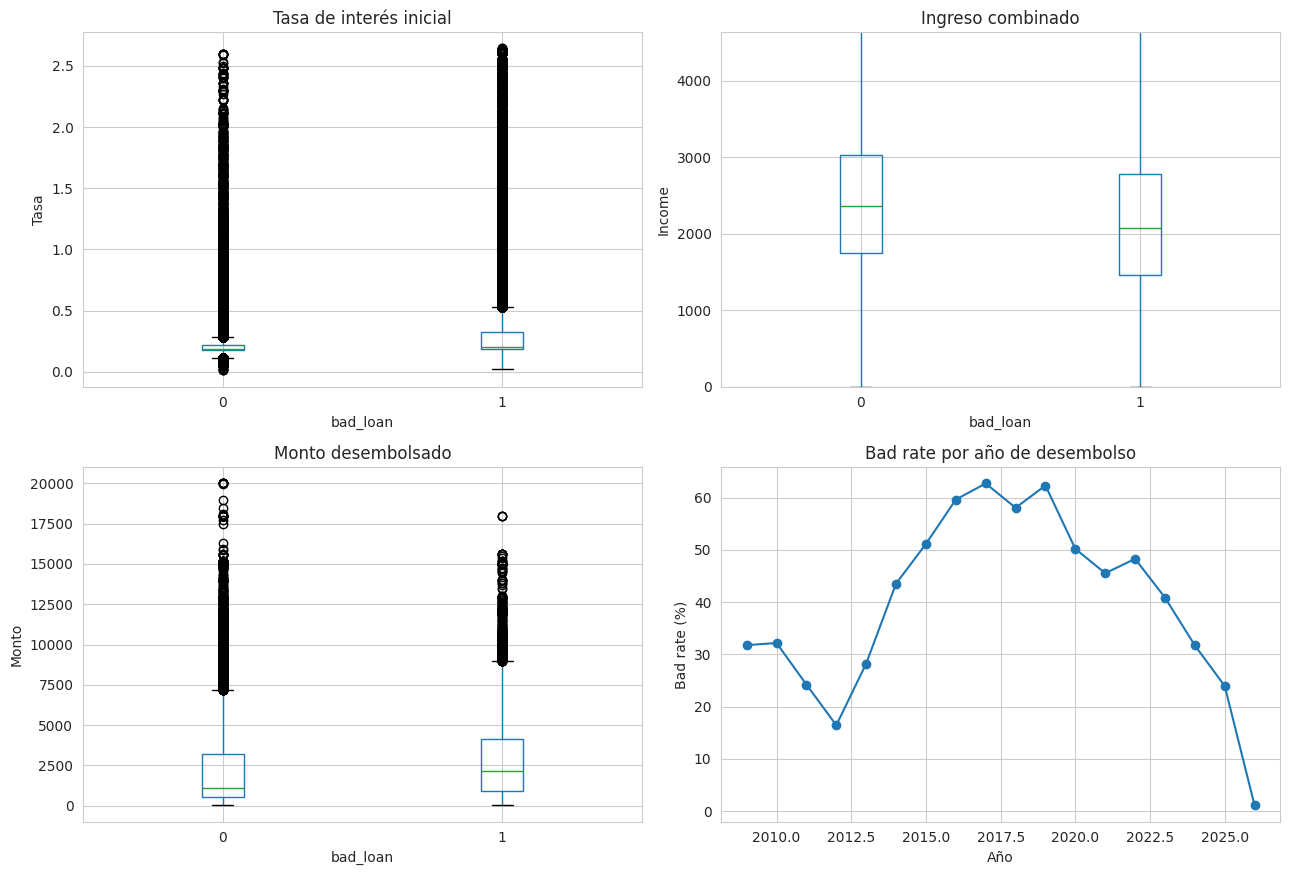

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Boxplot: interest rate por bad_loan
df_modelo.boxplot(column='initial_interest_rate', by='bad_loan', ax=axes[0, 0])
axes[0, 0].set_title('Tasa de interés inicial')
axes[0, 0].set_xlabel('bad_loan')
axes[0, 0].set_ylabel('Tasa')

# Boxplot: income por bad_loan
df_modelo.boxplot(column='combined_income', by='bad_loan', ax=axes[0, 1])
axes[0, 1].set_title('Ingreso combinado')
axes[0, 1].set_xlabel('bad_loan')
axes[0, 1].set_ylabel('Income')
axes[0, 1].set_ylim(0, df_modelo['combined_income'].quantile(0.95))  # quitamos outliers para ver mejor

# Boxplot: issued amount por bad_loan
df_modelo.boxplot(column='issued_amount', by='bad_loan', ax=axes[1, 0])
axes[1, 0].set_title('Monto desembolsado')
axes[1, 0].set_xlabel('bad_loan')
axes[1, 0].set_ylabel('Monto')

# Bad rate por año
df_modelo['year'] = df_modelo['loan_issued_at'].dt.year
bad_por_year = df_modelo.groupby('year')['bad_loan'].mean()
axes[1, 1].plot(bad_por_year.index, bad_por_year.values * 100, marker='o')
axes[1, 1].set_title('Bad rate por año de desembolso')
axes[1, 1].set_xlabel('Año')
axes[1, 1].set_ylabel('Bad rate (%)')
axes[1, 1].grid(True)

plt.suptitle('')  # quitamos el título automático feo
plt.tight_layout()
plt.show()

## 4. Detección y exclusión de data leakage

Clasificamos las 31 columnas en tres grupos: features válidos al momento de la solicitud, variables post-evento (leakage), y variables de outcome.

A través del análisis comparativo de medias entre clases, detectamos un caso adicional de leakage en `nr_of_payments` (5.7x de diferencia entre buenos y malos, un valor sospechoso). Lo excluimos.

**Features finales: 7 al momento de la solicitud + 5 dummies de país = 12 features.**

In [ ]:
# Variables disponibles AL MOMENTO DE LA SOLICITUD (las únicas que podemos usar)
features_validos = [
    'country',
    'loan_issued_at',          # podríamos sacar año/mes
    'issued_amount',
    'initial_interest_rate',
    'nr_of_payments',
    'initial_loan_duration',
    'combined_income',
    'customer_risk_rating',    # el rating que vamos a vencer
]

# Variables POST-evento (NO podemos usarlas como features — data leakage)
features_con_leakage = [
    'early_repaid_at', 'is_early_repaid_within_14_days',
    'principal_balance', 'principal_debt', 'principal_paid_total',
    'interest_paid_total', 'extra_interest_paid_total',
    'late_fee_paid_total', 'maintenance_fee_paid_total',
    'next_payment_nr', 'next_payment_date_local',
    'debt_occured_date_local', 'days_past_due_principal',
    'months_in_default', 'months_on_book', 'repaid_amount_total',
    'projected_npv_return',    # calculado post-hoc por Bondora
    'loan_last_recorded_action_date_local',
]

# Variables de "outcome" (relacionadas al target — tampoco se usan como features)
outcome_vars = ['loan_status', 'loan_status_risk', 'is_default',
                'has_default_within_12_months', 'bad_loan']

# Verificamos que clasificamos todo
todas = set(features_validos + features_con_leakage + outcome_vars + ['loan_id'])
faltantes = set(df_modelo.columns) - todas
sobrantes = todas - set(df_modelo.columns)
print(f"Columnas no clasificadas: {faltantes}")
print(f"Columnas inexistentes en mi clasificación: {sobrantes}")
print(f"\nTotal features válidos para modelar: {len(features_validos)}")

Columnas no clasificadas: {'year'}
Columnas inexistentes en mi clasificación: set()

Total features válidos para modelar: 8


In [ ]:
# 1) Estado de los nulos en df_modelo (puede ser distinto que en df)
print("Nulos por feature en df_modelo:")
nulos = df_modelo[features_validos].isnull().sum()
pct_nulos = (nulos / len(df_modelo) * 100).round(2)
print(pd.DataFrame({'nulos': nulos, 'pct_nulos': pct_nulos}))

print()
print("=" * 60)

# 2) Estadística clave: media de cada feature numérico por bad_loan
features_numericos = ['issued_amount', 'initial_interest_rate',
                       'nr_of_payments', 'initial_loan_duration',
                       'combined_income']

print("\nMedia de cada feature según bad_loan (0 = bueno, 1 = malo):")
comparacion = df_modelo.groupby('bad_loan')[features_numericos].mean().round(2)
print(comparacion.T)  # transpuesto se lee más fácil

Nulos por feature en df_modelo:
                        nulos  pct_nulos
country                     0       0.00
loan_issued_at              0       0.00
issued_amount               0       0.00
initial_interest_rate       0       0.00
nr_of_payments              0       0.00
initial_loan_duration       0       0.00
combined_income        229782      56.87
customer_risk_rating   274677      67.98


Media de cada feature según bad_loan (0 = bueno, 1 = malo):
bad_loan                     0        1
issued_amount          1994.05  2659.00
initial_interest_rate     0.21     0.28
nr_of_payments           10.15    58.04
initial_loan_duration    46.90    53.52
combined_income        2572.13  2314.45


In [ ]:
# Quitamos nr_of_payments de features válidos y lo movemos a leakage
features_validos = [
    'country',
    'loan_issued_at',
    'issued_amount',
    'initial_interest_rate',
    'initial_loan_duration',
    'combined_income',
    'customer_risk_rating',
]
# Ahora tenemos 7 features válidos
print(f"Features válidos corregidos: {len(features_validos)}")

Features válidos corregidos: 7


In [ ]:
# Features finales para el modelo (sin customer_risk_rating)
features_modelo = [
    'country',
    'loan_issued_at',
    'issued_amount',
    'initial_interest_rate',
    'initial_loan_duration',
    'combined_income',
]
print(f"Features para entrenar el modelo: {len(features_modelo)}")
print(f"customer_risk_rating queda reservado para la comparación final.")

Features para entrenar el modelo: 6
customer_risk_rating queda reservado para la comparación final.


## 5. Preparación de datos

- Creación del flag `income_missing` antes de imputar
- Imputación de `combined_income` con mediana por país
- One-hot encoding de la variable `country`
- Train/test split estratificado 80/20

In [ ]:
# Trabajamos sobre una copia para no romper df_modelo
df_prep = df_modelo.copy()

# 1) Extraemos el año del préstamo (útil como feature y para el split temporal)
df_prep['issue_year'] = df_prep['loan_issued_at'].dt.year

# 2) Flag binario: ¿el income estaba missing?
#    Esta variable suele tener poder predictivo en sí misma
df_prep['income_missing'] = df_prep['combined_income'].isnull().astype(int)

# 3) Imputamos income con la mediana POR PAÍS
#    (más realista que una mediana global)
df_prep['combined_income'] = df_prep.groupby('country')['combined_income'].transform(
    lambda x: x.fillna(x.median())
)

# Verificación
print("Verificación de nulos post-imputación:")
print(df_prep[['combined_income', 'income_missing']].isnull().sum())
print()
print(f"Cuántos préstamos tenían income missing: {df_prep['income_missing'].sum():,} ({df_prep['income_missing'].mean()*100:.1f}%)")
print()
print("Bad rate según income_missing:")
print(df_prep.groupby('income_missing')['bad_loan'].mean().round(4))

Verificación de nulos post-imputación:
combined_income    312
income_missing       0
dtype: int64

Cuántos préstamos tenían income missing: 229,782 (56.9%)

Bad rate según income_missing:
income_missing
0    0.3282
1    0.5313
Name: bad_loan, dtype: float64


In [ ]:
# One-hot encoding del país
# drop_first=True evita la "trampa de la dummy variable" (multicolinealidad)
df_prep = pd.get_dummies(df_prep, columns=['country'], prefix='country', drop_first=True)

# Las columnas country_X serán booleanas. Las convertimos a int para que sklearn no se queje
country_cols = [col for col in df_prep.columns if col.startswith('country_')]
df_prep[country_cols] = df_prep[country_cols].astype(int)

print(f"Columnas creadas: {country_cols}")
print()
print("Preview de las nuevas columnas:")
df_prep[country_cols].head()

Columnas creadas: ['country_Estonia', 'country_Finland', 'country_Latvia', 'country_Netherlands', 'country_Slovakia', 'country_Spain']

Preview de las nuevas columnas:


,country_Estonia,country_Finland,country_Latvia,country_Netherlands,country_Slovakia,country_Spain
2,0,1,0,0,0,0
5,0,1,0,0,0,0
6,0,0,0,1,0,0
7,1,0,0,0,0,0
10,0,1,0,0,0,0


In [ ]:
# 1) Resolver los 312 nulos residuales con mediana global
df_prep['combined_income'] = df_prep['combined_income'].fillna(
    df_prep['combined_income'].median()
)
print(f"Nulos restantes en combined_income: {df_prep['combined_income'].isnull().sum()}")

# 2) Lista final de features para el modelo
features_finales = [
    'issued_amount',
    'initial_interest_rate',
    'initial_loan_duration',
    'combined_income',
    'income_missing',
    'issue_year',
] + country_cols  # las dummies de país

print(f"\nFeatures totales: {len(features_finales)}")
print(features_finales)

# 3) Definir X (features) y y (target)
X = df_prep[features_finales].copy()
y = df_prep['bad_loan'].copy()

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

# 4) Train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducibilidad
    stratify=y            # mantiene el bad rate igual en ambos splits
)

print(f"\nX_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"\nBad rate en train: {y_train.mean()*100:.2f}%")
print(f"Bad rate en test:  {y_test.mean()*100:.2f}%")

Nulos restantes en combined_income: 0

Features totales: 12
['issued_amount', 'initial_interest_rate', 'initial_loan_duration', 'combined_income', 'income_missing', 'issue_year', 'country_Estonia', 'country_Finland', 'country_Latvia', 'country_Netherlands', 'country_Slovakia', 'country_Spain']

X shape: (404028, 12)
y shape: (404028,)

X_train: (323222, 12)
X_test:  (80806, 12)

Bad rate en train: 44.37%
Bad rate en test:  44.37%


## 6. Modelo baseline: Logistic Regression

Modelo lineal interpretable que sirve como benchmark obligatorio en credit scoring. Estándar regulatorio en banca real.

**Resultado: AUC = 0.6982**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

# 1) Escalado de features (importante para LR con regularización)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 2) Entrenamos el modelo
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

# 3) Predicciones
y_pred       = modelo_lr.predict(X_test_scaled)           # clase 0 o 1 (umbral 0.5)
y_pred_proba = modelo_lr.predict_proba(X_test_scaled)[:, 1]  # prob de ser bad_loan

# 4) Métrica clave: AUC
auc = roc_auc_score(y_test, y_pred_proba)
print(f"AUC (Logistic Regression baseline): {auc:.4f}")
print()

# 5) Matriz de confusión
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print()
print("Reporte de clasificación (con umbral 0.5):")
print(classification_report(y_test, y_pred, target_names=['Bueno (0)', 'Malo (1)']))


AUC (Logistic Regression baseline): 0.6982

Matriz de confusión:
[[33839 11111]
 [18006 17850]]

Reporte de clasificación (con umbral 0.5):
              precision    recall  f1-score   support

   Bueno (0)       0.65      0.75      0.70     44950
    Malo (1)       0.62      0.50      0.55     35856

    accuracy                           0.64     80806
   macro avg       0.63      0.63      0.62     80806
weighted avg       0.64      0.64      0.63     80806



In [ ]:
# Coeficientes: qué features mueven más la probabilidad de bad_loan
coef_df = pd.DataFrame({
    'feature': features_finales,
    'coef': modelo_lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

print("Importancia de features (ordenadas por magnitud absoluta):")
print(coef_df.to_string(index=False))

Importancia de features (ordenadas por magnitud absoluta):
              feature      coef
      country_Estonia -1.233500
      country_Finland -1.157625
        country_Spain -0.433117
  country_Netherlands -0.381930
initial_loan_duration  0.343220
initial_interest_rate  0.308907
        issued_amount  0.241029
       income_missing  0.209984
      combined_income -0.197739
       country_Latvia -0.162596
           issue_year -0.125121
     country_Slovakia -0.033289


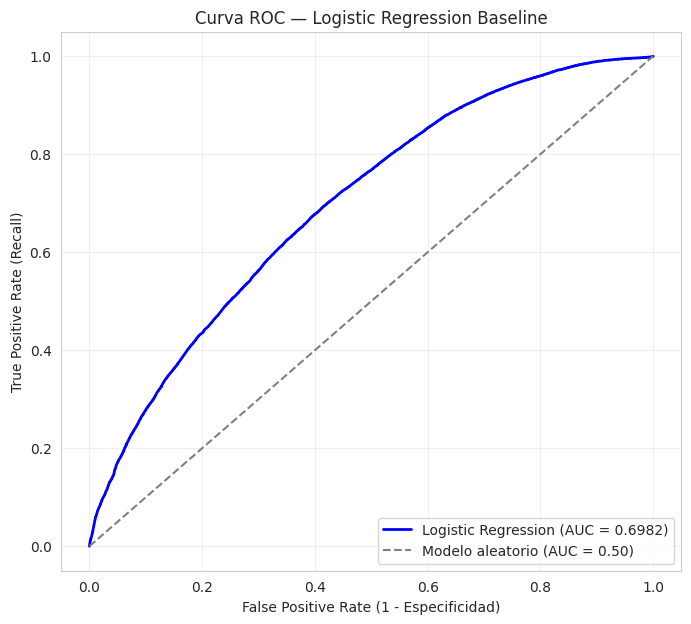

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calculamos los puntos de la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Graficamos
plt.figure(figsize=(8, 7))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Modelo aleatorio (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Especificidad)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC — Logistic Regression Baseline')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

## 7. Modelo principal: XGBoost

Gradient boosted trees que captura interacciones no-lineales entre features. No requiere escalado porque los árboles son invariantes a la escala absoluta.

**Resultado: AUC = 0.7526 (+5.4 puntos sobre el baseline)**

In [ ]:
# Instalamos XGBoost (Colab ya lo trae, pero por si acaso)
# !pip install xgboost  -- descomentar si te dice que no lo encuentra

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Entrenamos XGBoost
# Notas importantes:
# - eval_metric='auc' → XGBoost optimiza directo por AUC durante entrenamiento
# - n_estimators=300 → número de árboles
# - max_depth=5 → profundidad de cada árbol (más alto = más complejo pero overfitting)
# - learning_rate=0.1 → cuánto "aprende" cada árbol (más bajo = más estable)
# - random_state=42 → reproducibilidad

modelo_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,        # usa todos los cores del procesador
)

modelo_xgb.fit(X_train, y_train)
# Notar: con XGBoost NO necesitamos escalar features. Los árboles no se afectan por escala.

# Predicciones
y_pred_xgb       = modelo_xgb.predict(X_test)
y_pred_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Evaluación
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"AUC XGBoost: {auc_xgb:.4f}")
print(f"AUC Logistic Regression: {auc:.4f}")
print(f"Mejora absoluta: +{(auc_xgb - auc)*100:.2f} puntos")
print()

print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))
print()
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred_xgb, target_names=['Bueno (0)', 'Malo (1)']))

AUC XGBoost: 0.7526
AUC Logistic Regression: 0.6982
Mejora absoluta: +5.44 puntos

Matriz de confusión:
[[31683 13267]
 [12463 23393]]

Reporte de clasificación:
              precision    recall  f1-score   support

   Bueno (0)       0.72      0.70      0.71     44950
    Malo (1)       0.64      0.65      0.65     35856

    accuracy                           0.68     80806
   macro avg       0.68      0.68      0.68     80806
weighted avg       0.68      0.68      0.68     80806



Importancia de features (XGBoost):
              feature  importance
        country_Spain    0.306279
initial_loan_duration    0.192269
      country_Estonia    0.179423
initial_interest_rate    0.081084
           issue_year    0.064404
      country_Finland    0.035968
  country_Netherlands    0.034295
        issued_amount    0.032435
      combined_income    0.028742
       income_missing    0.020051
     country_Slovakia    0.017749
       country_Latvia    0.007300


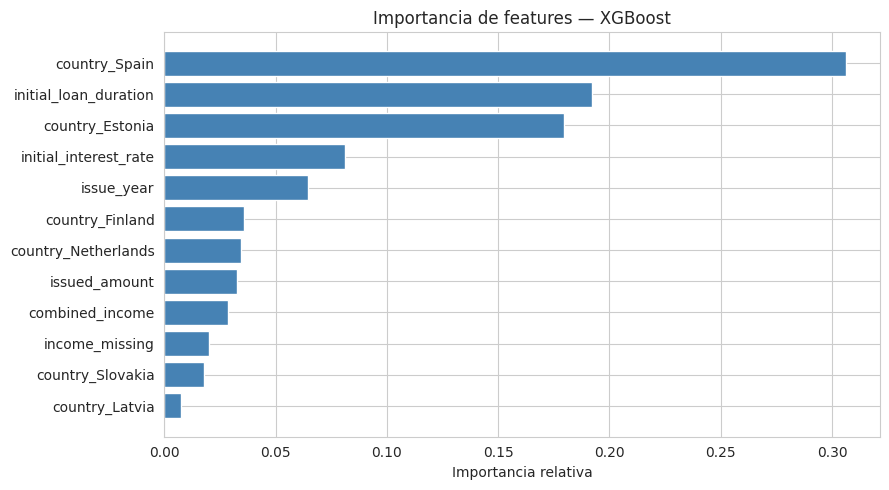

In [ ]:
# Importancia de features en XGBoost
import pandas as pd

feat_importance = pd.DataFrame({
    'feature': features_finales,
    'importance': modelo_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print("Importancia de features (XGBoost):")
print(feat_importance.to_string(index=False))

# Visualización
import matplotlib.pyplot as plt
plt.figure(figsize=(9, 5))
plt.barh(feat_importance['feature'][::-1], feat_importance['importance'][::-1], color='steelblue')
plt.xlabel('Importancia relativa')
plt.title('Importancia de features — XGBoost')
plt.tight_layout()
plt.show()

## 8. Comparación cabeza a cabeza vs rating de Bondora

Filtramos el test set a préstamos con `customer_risk_rating` disponible (25,942 préstamos) y comparamos AUC.

**Resultado: nuestro XGBoost vence a Bondora en +8.61 puntos AUC y +49.8% en Gini.**

In [ ]:
from sklearn.metrics import roc_auc_score

# 1) Reconstruir el test set con todas sus columnas originales
test_full = df_prep.loc[X_test.index].copy()
test_full['our_pred_proba'] = y_pred_proba_xgb

# 2) Filtrar a solo los préstamos con rating (excluyendo HR por ser anecdótico)
test_rated = test_full[
    test_full['customer_risk_rating'].notna() &
    (test_full['customer_risk_rating'] != 'HR')
].copy()

print(f"Test set total:                  {len(test_full):,}")
print(f"Test set con rating de Bondora:  {len(test_rated):,}")
print(f"% del test que tiene rating:     {len(test_rated)/len(test_full)*100:.1f}%")

# 3) Encodear el rating de Bondora ordinalmente (mayor número = mayor riesgo)
rating_map = {'AA': 0, 'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
test_rated['bondora_score'] = test_rated['customer_risk_rating'].map(rating_map)

# 4) Calcular AUC de cada modelo sobre la misma muestra
auc_bondora = roc_auc_score(test_rated['bad_loan'], test_rated['bondora_score'])
auc_ours    = roc_auc_score(test_rated['bad_loan'], test_rated['our_pred_proba'])

# Gini coefficient (cousin de AUC, se usa más en banca europea)
gini_bondora = 2 * auc_bondora - 1
gini_ours    = 2 * auc_ours - 1

# 5) Resultado
print("\n" + "=" * 55)
print("       COMPARACIÓN CABEZA A CABEZA")
print("=" * 55)
print(f"  AUC Bondora rating:    {auc_bondora:.4f}   (Gini: {gini_bondora:.4f})")
print(f"  AUC XGBoost (nuestro): {auc_ours:.4f}   (Gini: {gini_ours:.4f})")
print(f"  Mejora absoluta AUC:   +{(auc_ours - auc_bondora)*100:.2f} puntos")
print(f"  Mejora relativa Gini:  +{((gini_ours/gini_bondora) - 1)*100:.1f}%")
print("=" * 55)

Test set total:                  80,806
Test set con rating de Bondora:  25,942
% del test que tiene rating:     32.1%

       COMPARACIÓN CABEZA A CABEZA
  AUC Bondora rating:    0.6731   (Gini: 0.3462)
  AUC XGBoost (nuestro): 0.7593   (Gini: 0.5185)
  Mejora absoluta AUC:   +8.61 puntos
  Mejora relativa Gini:  +49.8%


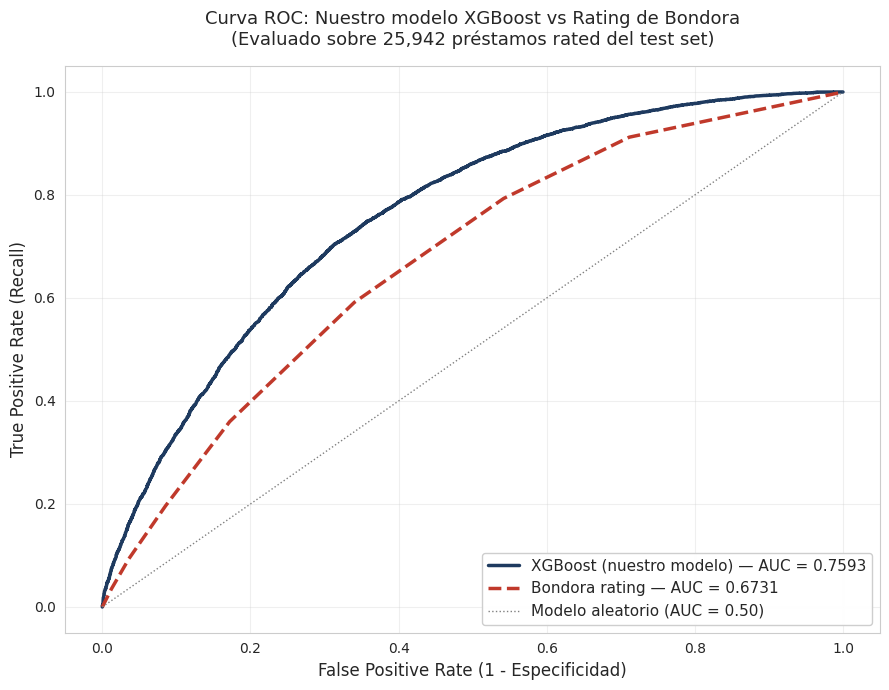

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# Calcular las curvas ROC sobre la submuestra rated
fpr_xgb, tpr_xgb, _ = roc_curve(test_rated['bad_loan'], test_rated['our_pred_proba'])
fpr_bon, tpr_bon, _ = roc_curve(test_rated['bad_loan'], test_rated['bondora_score'])

# Plot
plt.figure(figsize=(9, 7))
plt.plot(fpr_xgb, tpr_xgb, color='#1e3a5f', linewidth=2.5,
         label=f'XGBoost (nuestro modelo) — AUC = {auc_ours:.4f}')
plt.plot(fpr_bon, tpr_bon, color='#c0392b', linewidth=2.5, linestyle='--',
         label=f'Bondora rating — AUC = {auc_bondora:.4f}')
plt.plot([0, 1], [0, 1], color='gray', linewidth=1, linestyle=':',
         label='Modelo aleatorio (AUC = 0.50)')

plt.xlabel('False Positive Rate (1 - Especificidad)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('Curva ROC: Nuestro modelo XGBoost vs Rating de Bondora\n'
          f'(Evaluado sobre {len(test_rated):,} préstamos rated del test set)',
          fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=11, framealpha=0.95)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Guardar la figura
plt.savefig('/content/drive/MyDrive/Codigos/roc_comparison.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 9. Análisis por deciles

Estratificamos el portafolio en 10 grupos según el score predicho y medimos el bad rate observado en cada uno.

**Resultado: lift de 12.2x entre decil 10 (79% bad rate) y decil 1 (6.5% bad rate).**

       n_prestamos  bad_rate  score_min  score_max  bad_rate_pct
decil                                                           
1             8108    0.0655     0.0005     0.1191          6.55
2             8058    0.1720     0.1191     0.2298         17.20
3             8259    0.2773     0.2298     0.3230         27.73
4             7914    0.3618     0.3230     0.4067         36.18
5             8065    0.4443     0.4067     0.4733         44.43
6             8100    0.4991     0.4733     0.5292         49.91
7             8603    0.5512     0.5292     0.5663         55.12
8             7558    0.5994     0.5663     0.6325         59.94
9             8064    0.6830     0.6325     0.7281         68.30
10            8077    0.7899     0.7281     0.9727         78.99


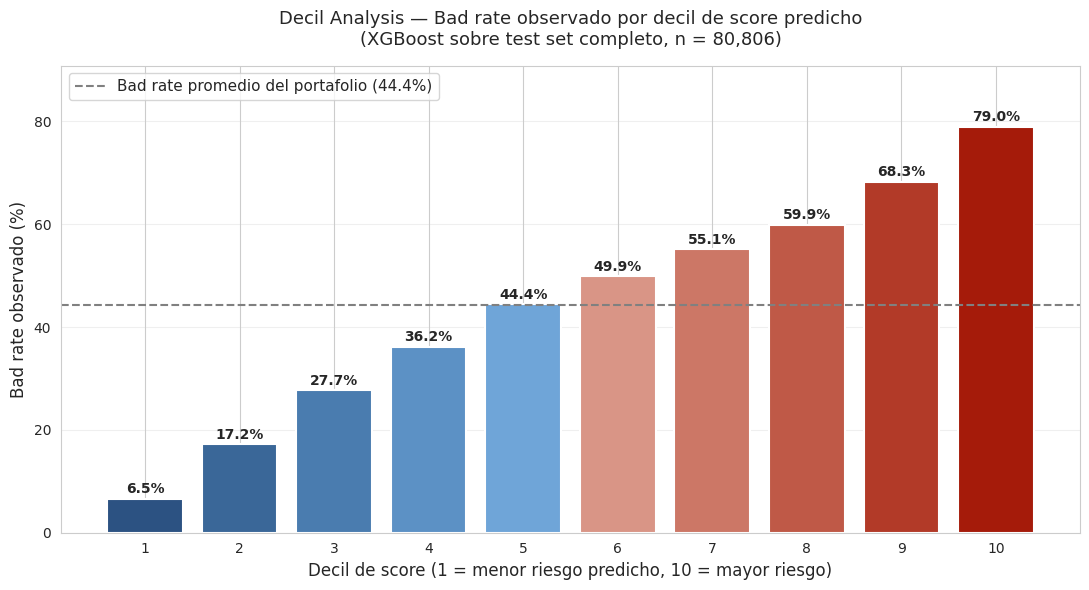

In [ ]:
import numpy as np

# Trabajamos sobre el test set completo (no solo rated)
test_full['decil'] = pd.qcut(test_full['our_pred_proba'],
                              q=10, labels=range(1, 11),
                              duplicates='drop')

# Calcular bad rate y cantidad por decil
decil_stats = test_full.groupby('decil', observed=True).agg(
    n_prestamos=('bad_loan', 'count'),
    bad_rate=('bad_loan', 'mean'),
    score_min=('our_pred_proba', 'min'),
    score_max=('our_pred_proba', 'max'),
).round(4)
decil_stats['bad_rate_pct'] = (decil_stats['bad_rate'] * 100).round(2)
print(decil_stats)

# Plot
fig, ax = plt.subplots(figsize=(11, 6))

colors = ['#2c5282', '#3a6798', '#4a7caf', '#5c91c5', '#6fa5d8',
          '#d99586', '#cc7766', '#bf5947', '#b23a28', '#a51b0a']
bars = ax.bar(range(1, 11), decil_stats['bad_rate_pct'], color=colors,
              edgecolor='white', linewidth=1.5)

# Línea horizontal: bad rate promedio
avg_bad_rate = test_full['bad_loan'].mean() * 100
ax.axhline(y=avg_bad_rate, color='gray', linestyle='--', linewidth=1.5,
           label=f'Bad rate promedio del portafolio ({avg_bad_rate:.1f}%)')

# Etiquetas en cada barra
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_xlabel('Decil de score (1 = menor riesgo predicho, 10 = mayor riesgo)',
              fontsize=12)
ax.set_ylabel('Bad rate observado (%)', fontsize=12)
ax.set_title('Decil Analysis — Bad rate observado por decil de score predicho\n'
             '(XGBoost sobre test set completo, n = 80,806)',
             fontsize=13, pad=15)
ax.set_xticks(range(1, 11))
ax.set_ylim(0, max(decil_stats['bad_rate_pct']) * 1.15)
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

plt.savefig('/content/drive/MyDrive/Codigos/decil_analysis.png',
            dpi=200, bbox_inches='tight')
plt.show()

## 10. Generación de score crediticio y exportación

Como capa de presentación, transformamos la probabilidad predicha en un score numérico tipo FICO usando la fórmula estándar: `Score = Offset − Factor × ln(odds)`.

Exportamos tres archivos CSV para uso posterior en Power BI:
- `predicciones_test.csv` — predicciones a nivel préstamo
- `decil_stats.csv` — estadísticas por decil
- `resumen_metricas.csv` — KPIs principales

In [ ]:
# Recuperar el país desde df_modelo (que aún tiene la columna original)
test_full['country'] = df_modelo.loc[test_full.index, 'country']

# 1) CSV con predicciones + datos clave para Power BI
df_export = test_full[[
    'country', 'issued_amount', 'initial_interest_rate',
    'initial_loan_duration', 'combined_income', 'income_missing',
    'issue_year', 'customer_risk_rating',
    'bad_loan', 'our_pred_proba', 'decil'
]].copy()

df_export.to_csv('/content/drive/MyDrive/Codigos/predicciones_test.csv',
                  index=False)
print(f"✓ CSV exportado: {len(df_export):,} filas")

# 2) Tabla de deciles para Power BI
decil_stats.to_csv('/content/drive/MyDrive/Codigos/decil_stats.csv')
print(f"✓ Decil stats exportadas")

# 3) Tabla resumen de resultados clave
resumen = pd.DataFrame({
    'metrica': ['AUC Logistic Regression', 'AUC XGBoost', 'AUC Bondora rating',
                'Mejora vs Bondora (AUC)', 'Gini XGBoost', 'Gini Bondora',
                'Lift decil 10 vs 1', 'Bad rate decil 1', 'Bad rate decil 10',
                'Test set total', 'Test set rated', 'Bad rate portafolio'],
    'valor': [0.6982, 0.7593, 0.6731, 0.0861, 0.5185, 0.3462,
              12.2, 0.0655, 0.7899, 80806, 25942, 0.4437]
})
resumen.to_csv('/content/drive/MyDrive/Codigos/resumen_metricas.csv', index=False)
print(f"✓ Resumen exportado")

print("\nTodos los archivos están en /MyDrive/Codigos/")

✓ CSV exportado: 80,806 filas
✓ Decil stats exportadas
✓ Resumen exportado

Todos los archivos están en /MyDrive/Codigos/


In [ ]:
import numpy as np

# === 1) RATING EN LETRAS (estilo Bondora) ===
mapa_letras = {1:'AA', 2:'A', 3:'B+', 4:'B', 5:'C+',
               6:'C', 7:'D+', 8:'D', 9:'E', 10:'F'}
df_export['rating_propio'] = df_export['decil'].map(mapa_letras)

# === 2) SCORE TIPO FICO (300 a 850) ===
# Fórmula estándar: Score = Offset - Factor * ln(odds)
# Calibramos para que el rango quede entre ~300 y ~850

# Parámetros estándar de la industria
PDO = 20      # Points to Double Odds: cada 20 puntos, las odds se duplican
BASE_ODDS = 50  # odds base (50:1 a favor de no default)
BASE_SCORE = 600  # score correspondiente a las odds base

Factor = PDO / np.log(2)
Offset = BASE_SCORE - Factor * np.log(BASE_ODDS)

# Calcular el score
# Recordar: prob es la probabilidad de bad_loan = 1
prob = df_export['our_pred_proba'].clip(0.001, 0.999)  # evitar log(0)
odds = (1 - prob) / prob                                # odds de NO default
df_export['credit_score'] = (Offset + Factor * np.log(odds)).round().astype(int)

# Limitar al rango FICO clásico (300-850)
df_export['credit_score'] = df_export['credit_score'].clip(300, 850)

# === 3) Resumen para verificar ===
print("Resumen del score generado:")
print(df_export['credit_score'].describe().round(0))
print()
print("Bad rate por rango de score (segmentación tipo banco):")
df_export['score_bucket'] = pd.cut(
    df_export['credit_score'],
    bins=[300, 500, 600, 650, 700, 750, 850],
    labels=['Subprime (300-500)', 'Fair (500-600)', 'Average (600-650)',
            'Good (650-700)', 'Very Good (700-750)', 'Excellent (750-850)']
)
print(df_export.groupby('score_bucket', observed=True)['bad_loan'].agg(['count', 'mean']).round(4))

# Re-exportar con las nuevas columnas
df_export.to_csv('/content/drive/MyDrive/Codigos/predicciones_test.csv', index=False)
print("\n✓ CSV actualizado con rating_propio y credit_score")

Resumen del score generado:
count    80806.0
mean       497.0
std         35.0
min        384.0
25%        476.0
50%        490.0
75%        515.0
max        686.0
Name: credit_score, dtype: float64

Bad rate por rango de score (segmentación tipo banco):
                    count    mean
score_bucket                     
Subprime (300-500)  51036  0.5838
Fair (500-600)      29078  0.2083
Average (600-650)     390  0.0128
Good (650-700)        302  0.0033

✓ CSV actualizado con rating_propio y credit_score
